<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_2_5_ge(Me)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Нелинейная регрессия ge(Me)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Загрузка данных и конвертация в CSV
file_name = '/content/multiregress042020.xlsx'
df = pd.read_excel(file_name, header=1)
csv_file_name = 'multiregress042020.csv'
df.to_csv(csv_file_name, index=False, encoding='utf-8-sig')


# Создаю переменные
x = df['Me'].values
y = df['ge'].values

# Проверка перых 3 строк
print(df.head(3))

   i    ne   Me    tc      ge    CO2     NOx
0  1  1200  140  80.7  233.16   5.88  665.25
1  2  1200  210  82.8  225.23   8.67  900.50
2  3  1200  252  83.2  232.83  10.58  957.19


In [4]:
# Функция для расчета коэффициента детерминации R^2
def calc_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

# Описание математических функций моделей
def power_model(x, a, b):
    return a * (x ** b)

def exp_model(x, a, b):
    return a * np.exp(b * x)

def hyper_model(x, a, b):
    return a + (b / x)

In [5]:
# Подгонка моделей и расчет R^2
results = {}

# Степенная модель
popt_power, _ = curve_fit(power_model, x, y)
y_power = power_model(x, *popt_power)
results['Степенная'] = {
    'r2': calc_r2(y, y_power),
    'eq': f"ge = {popt_power[0]:.2f} * Me^{popt_power[1]:.4f}"
}

# Показательная модель
popt_exp, _ = curve_fit(exp_model, x, y, p0=(np.mean(y), -0.01))
y_exp = exp_model(x, *popt_exp)
results['Показательная'] = {
    'r2': calc_r2(y, y_exp),
    'eq': f"ge = {popt_exp[0]:.2f} * e^({popt_exp[1]:.5f} * Me)"
}

# Гиперболическая модель
popt_hyper, _ = curve_fit(hyper_model, x, y)
y_hyper = hyper_model(x, *popt_hyper)
results['Гиперболическая'] = {
    'r2': calc_r2(y, y_hyper),
    'eq': f"ge = {popt_hyper[0]:.2f} + {popt_hyper[1]:.2f} / Me"
}

# Полиномиальная модель 2-го порядка
popt_poly = np.polyfit(x, y, 2)
y_poly = np.polyval(popt_poly, x)
results['Полиномиальная (2-й порядок)'] = {
    'r2': calc_r2(y, y_poly),
    'eq': f"ge = {popt_poly[0]:.5f}*Me^2 + {popt_poly[1]:.2f}*Me + {popt_poly[2]:.2f}"
}

In [8]:
# Вывод результатов в консоль
print("Сравнение моделей ge(Me)\n")
for name, data in results.items():
    print(f"{name:28} | R^2 = {data['r2']:<6.4f} | {data['eq']}")

# Определение наилучшей модели (с максимальным R^2)
best_model = max(results, key=lambda k: results[k]['r2'])
print(f"ВЫВОД: Наиболее точной для прогнозирования является '{best_model}' модель.")
print(f"Она объясняет {results[best_model]['r2'] * 100:.2f}% дисперсии (максимальный R^2).")

Сравнение моделей ge(Me)

Степенная                    | R^2 = 0.8741 | ge = 1944.25 * Me^-0.4084
Показательная                | R^2 = 0.6504 | ge = 496.49 * e^(-0.00392 * Me)
Гиперболическая              | R^2 = 0.9417 | ge = 184.62 + 9192.40 / Me
Полиномиальная (2-й порядок) | R^2 = 0.8562 | ge = 0.01212*Me^2 + -4.39*Me + 600.17
ВЫВОД: Наиболее точной для прогнозирования является 'Гиперболическая' модель.
Она объясняет 94.17% дисперсии (максимальный R^2).


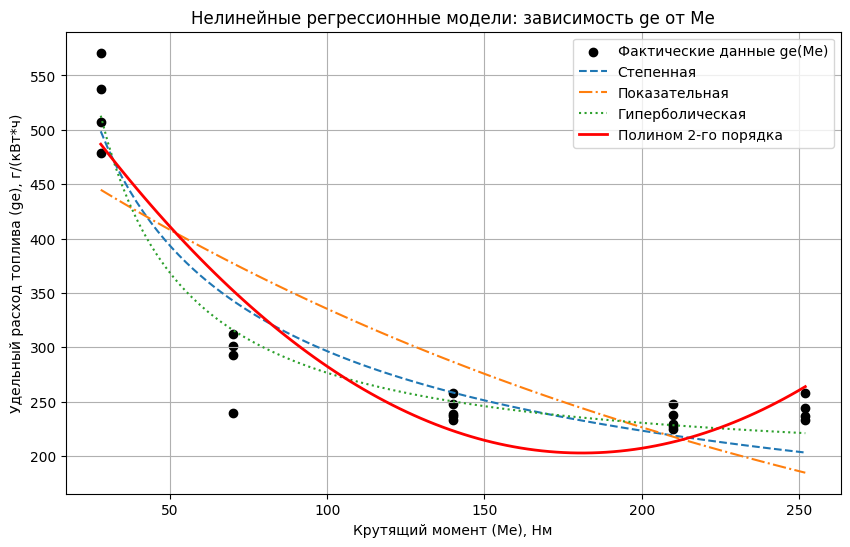

In [9]:
# Визуализация всех моделей на одном графике
plt.figure(figsize=(10, 6))

# Генерируем точки x для плавности отрисовки кривых
x_plot = np.linspace(min(x), max(x), 100)

plt.scatter(x, y, color='black', label='Фактические данные ge(Me)')
plt.plot(x_plot, power_model(x_plot, *popt_power), label='Степенная', linestyle='--')
plt.plot(x_plot, exp_model(x_plot, *popt_exp), label='Показательная', linestyle='-.')
plt.plot(x_plot, hyper_model(x_plot, *popt_hyper), label='Гиперболическая', linestyle=':')
plt.plot(x_plot, np.polyval(popt_poly, x_plot), label='Полином 2-го порядка', color='red', linewidth=2)

plt.title('Нелинейные регрессионные модели: зависимость ge от Me')
plt.xlabel('Крутящий момент (Me), Нм')
plt.ylabel('Удельный расход топлива (ge), г/(кВт*ч)')
plt.legend()
plt.grid(True)
plt.show()